In [1]:
# Add description here
#

In [2]:
# Uncomment the next two lines to enable auto reloading for imported modules
# %load_ext autoreload
# %autoreload 2
# For more info, see:
# https://docs.ploomber.io/en/latest/user-guide/faq_index.html#auto-reloading-code-in-jupyter

In [3]:
# If this task has dependencies, list them them here
# (e.g. upstream = ['some_task']), otherwise leave as None.
upstream = None

# This is a placeholder, leave it as None
product = None
taxonomy_source = None
count_threshold = None
sampling_table_source = None
library_table_source = None
rank = None

In [4]:
# Parameters
count_threshold = 10
taxonomy_source = "gtdb-taxonomy-reference.json"
sampling_table_source = "../../data/mcleish2024/nph20054-sup-0002-TablesS1.csv"
library_table_source = "../../data/mcleish2024/nph20054-sup-0002-TablesS2.csv"
rank = "species"
product = {"nb": "/home/bcz/research/miripvir25/results/2025-04-21-mmseqs2-preprocess/products/out.process.ipynb", "count": "/home/bcz/research/miripvir25/results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json", "histogram_contigs_per_hit": "/home/bcz/research/miripvir25/results/2025-04-21-mmseqs2-preprocess/products/contigs-per-hit.png"}


## Load dependencies

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import taxoniq
from seaborn import objects as so
import numpy as np
sns.set_style('ticks')
plt.rcParams['svg.fonttype'] = 'none'
import re

## Load data 

In [6]:
def load_library_taxonomy_results(file, path, library):
    """
    assigning labels from reading https://mmseqs.com/latest/userguide.pdf, taxonomy output and TSV
    """
    u = pd.read_csv(
        path + '/' + file, 
        sep='\t', 
        header=None, 
        index_col=None,
        names=['seq_id', 'taxid', 'level', 'species_name', 'fragments', 'frag_labeled', 'agreement', 'support']
    )
    u['library'] = library

    return u[['library', 'seq_id', 'taxid', 'level', 'species_name', 'fragments', 'support']]


This function solves some minor format issues with the library names.

In [7]:
def fix_numeric_format_issues(x):
    m = re.search("PV(\d{1,6})(\w{1,10})?", x)
    m = list(m.groups())
    if m[1] is not None:
        return 'PV{:03d}{:s}'.format(int(m[0]), m[1])
    else:
        return 'PV{:03d}'.format(int(m[0]))
    
print(fix_numeric_format_issues("PV03bgi"))
print(fix_numeric_format_issues("PV00003bgi"))
print(fix_numeric_format_issues("PV00003"))
print(fix_numeric_format_issues("PV00003asdasda"))

PV003bgi
PV003bgi
PV003
PV003asdasda


## Load reference 

The `.input` file is key here.

In [8]:
input_reference = pd.read_csv("input-data/.input", header=None, names=["file"])
input_reference['library'] = input_reference['file'].apply(lambda x: fix_numeric_format_issues(x))
input_reference

,file,library
0,PV003bgi.taxonomy.tsv,PV003bgi
1,PV004bgi.taxonomy.tsv,PV004bgi
2,PV005bgi.taxonomy.tsv,PV005bgi
3,PV006bgi.taxonomy.tsv,PV006bgi
4,PV007bgi.taxonomy.tsv,PV007bgi
...,...,...
313,PV96.taxonomy.tsv,PV096
314,PV97.taxonomy.tsv,PV097
315,PV98.taxonomy.tsv,PV098
316,PV99.taxonomy.tsv,PV099


The following loop loads all the data.

In [9]:
taxonomy_output = []
for i, row in tqdm.tqdm(list(input_reference.iterrows())):
    tmp = load_library_taxonomy_results(
        row.file, 
        "input-data/",
        row.library
    )
    taxonomy_output.append(tmp)
taxonomy_output = pd.concat(taxonomy_output)
taxonomy_output

  0%|                                      | 0/318 [00:00<?, ?it/s]

  1%|▏                             | 2/318 [00:00<00:40,  7.78it/s]

  1%|▎                             | 3/318 [00:00<00:51,  6.17it/s]

  1%|▍                             | 4/318 [00:00<00:55,  5.65it/s]

  2%|▍                             | 5/318 [00:00<00:55,  5.67it/s]

...

 99%|███████████████████████████▊| 316/318 [00:56<00:00,  3.39it/s]

100%|███████████████████████████▉| 317/318 [00:57<00:00,  3.30it/s]

100%|████████████████████████████| 318/318 [00:57<00:00,  3.81it/s]

100%|████████████████████████████| 318/318 [00:57<00:00,  5.53it/s]

,library,seq_id,taxid,level,species_name,fragments,support
0,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:26007:5686,0,no rank,unclassified,1,0.0
1,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:28899:66812,0,no rank,unclassified,1,0.0
2,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1109:18923:5827,0,no rank,unclassified,1,0.0
3,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1103:22719:38034,0,no rank,unclassified,1,0.0
4,PV003bgi,ST-E00169:248:H5VT5ALXX:5:1101:18558:53926,0,no rank,unclassified,1,0.0
...,...,...,...,...,...,...,...
140551,PV009,J00148:8:HFKGWBBXX:2:1119:26910:9403,0,no rank,unclassified,1,0.0
140552,PV009,J00148:8:HFKGWBBXX:2:1119:6076:24894,0,no rank,unclassified,1,0.0
140553,PV009,J00148:8:HFKGWBBXX:2:1119:18680:41141,0,no rank,unclassified,1,0.0
140554,PV009,J00148:8:HFKGWBBXX:2:1120:15412:14590,0,no rank,unclassified,1,0.0


## Removing unclassified reads

Plotting classified vs unclassified reads.

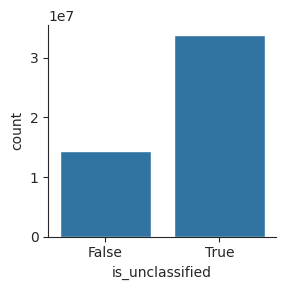

In [10]:
taxonomy_output['is_unclassified'] = taxonomy_output['taxid'] == 0
sns.catplot(
    taxonomy_output.value_counts(subset=['is_unclassified']).reset_index(), 
    x='is_unclassified', y='count', height=3.0, aspect=1.0, kind='bar'
)

Removing not-classified reads.

In [11]:
taxonomy_output = taxonomy_output.query('is_unclassified == False').copy()

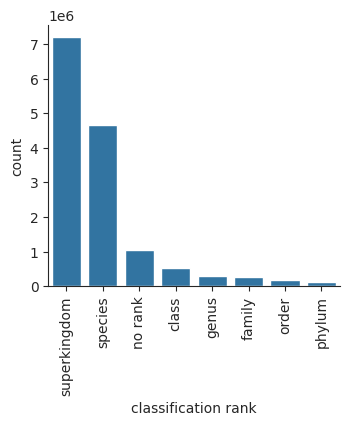

In [12]:
g = sns.catplot(
    data=taxonomy_output.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xlabels("classification rank")
g.set_xticklabels(rotation=90)

## Cross-referencing with environmental / library data

Loading McLeish supplementary tables 1 and 2, and cross-referencing our data. 

In [13]:
mc24_table1 = pd.read_csv(sampling_table_source, sep=';')
mc24_table2 = pd.read_csv(library_table_source, sep=';')
mc24_table2 = mc24_table2.dropna(subset=['Library_code'])
mc24_table2['Collection_code'] = mc24_table2['Collection_code'].apply(lambda x: x.split("_")[0])
sample_reference = pd.merge(mc24_table1, mc24_table2, on='Collection_code').groupby(['Site_code', 'Collection_code', 'Library_code', 'Location', 'Host_taxon', 'Habitat', 'No_extracts'], as_index=False)['Date'].apply(lambda x: len(list(x)))
sample_reference

,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,C1,C1F,PV534,Aranjuez,Diplotaxis erucoides,Crop,3.0,1
1,C1,C1F,PV535,Aranjuez,Brassica oleracea,Crop,17.0,1
2,C1,C1F,PV538,Aranjuez,Brassica oleracea,Crop,8.0,1
3,C1,C1F,PV540,Aranjuez,Picris echioides,Crop,1.0,1
4,C1,C1F,PV544,Aranjuez,Sisymbrium runcinatum,Crop,4.0,1
...,...,...,...,...,...,...,...,...
318,Z1,Z1V,PV590,Villaconejos,Zea mays,Crop,11.0,1
319,Z2,Z2V,PV047,Villamanrique de Tajo,Zea mays,Crop,13.0,1
320,Z2,Z2V,PV048,Villamanrique de Tajo,Desconocida 4,Crop,9.0,1
321,Z2,Z2V,PV527,Villamanrique de Tajo,Convolvulus arvensis,Crop,4.0,1


In [14]:
taxonomy_output = pd.merge(taxonomy_output, sample_reference, left_on='library', right_on='Library_code')

## Cross-referencing taxonomy

Loading taxonomy

In [15]:
taxonomy_reference = pd.read_json(taxonomy_source)

Merge

In [16]:
taxonomy_output = pd.merge(taxonomy_output, taxonomy_reference, on='taxid')

## Counting hits by library / species

In [17]:
taxonomy_output_counts = taxonomy_output.value_counts(
    subset=[
        'library', 'taxid', 'level', 'species_name', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'Site_code', 
        'Collection_code', 'Host_taxon', 'Habitat'
    ], dropna=False
).reset_index()
taxonomy_output_counts

,library,taxid,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count
0,PV580,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,Q2,Q2F,Rhamnus lycioides,Oak,110248
1,PV588,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,H1,H1P,Hordeum vulgare,Crop,95141
2,PV070,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,E1,E1F,Descurainia sophia,Wasteland,86241
3,PV574,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,Q3,Q3P,Helianthemum cinereum,Oak,77626
4,PV566,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,E2,E2F,Retama sphaerocarpa,Wasteland,76211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513445,PV155,85822,species,PUPC01 sp003553185,Planctomycetota,PUPC01,PUPC01,PUPC01,PUPC01,PUPC01 sp003553185,L4,L4P,Fumaria parviflora,Edge,1
513446,PV155,85537,species,Actinophytocola xanthii,Actinomycetota,Actinomycetes,Mycobacteriales,Pseudonocardiaceae,Actinophytocola,Actinophytocola xanthii,L4,L4P,Fumaria parviflora,Edge,1
513447,PV155,85438,species,JAKBEL01 sp029262575,Dependentiae,Babeliae,Babeliales,Vermiphilaceae,JAKBEL01,JAKBEL01 sp029262575,L4,L4P,Fumaria parviflora,Edge,1
513448,PV155,85316,species,JAUVAN01 sp030621515,Myxococcota,Polyangia,JAAYKL01,JAAYKL01,JAUVAN01,JAUVAN01 sp030621515,L4,L4P,Fumaria parviflora,Edge,1


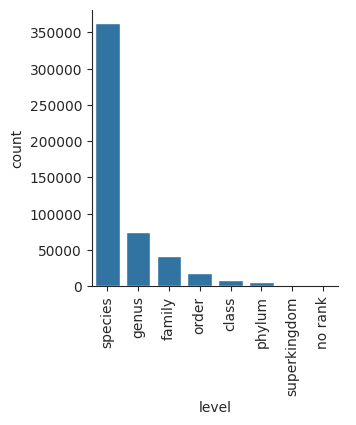

In [18]:
g = sns.catplot(
    data=taxonomy_output_counts.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=90)

## Removing counts below `count_threshold`

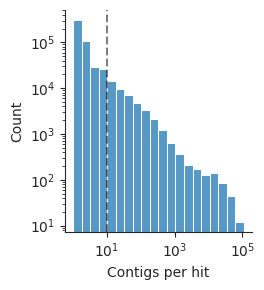

In [19]:
g = sns.displot(taxonomy_output_counts, x='count', height=3, bins=20, log_scale=(True, False))
g.axes[0,0].set_yscale('log')
g.axes[0,0].axvline(count_threshold, color="black", alpha=0.5, linewidth=1.5, linestyle='--')
g.set_xlabels("Contigs per hit", )
g.savefig(product['histogram_contigs_per_hit'])

In [20]:
taxonomy_output_counts = taxonomy_output_counts.query(f'count > {count_threshold}')

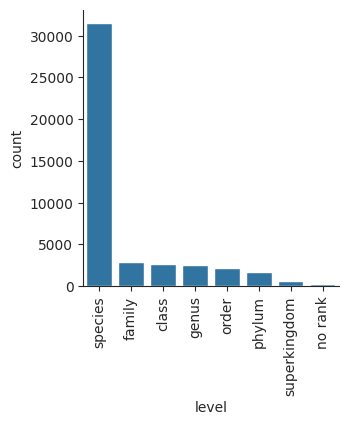

In [21]:
g = sns.catplot(
    data=taxonomy_output_counts.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=90)

## Filter by taxonomic rank

In [22]:
category_level = ["no rank", "superkingdom", "phylum", "class", "order", "family", "genus", "species"]

In [23]:
taxonomy_output_counts['taxonomic_category'] = taxonomy_output_counts['level'].apply(lambda x: category_level.index(x))
taxonomy_output_counts

/tmp/ipykernel_594164/3063452890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxonomy_output_counts['taxonomic_category'] = taxonomy_output_counts['level'].apply(lambda x: category_level.index(x))


,library,taxid,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count,taxonomic_category
0,PV580,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,Q2,Q2F,Rhamnus lycioides,Oak,110248,1
1,PV588,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,H1,H1P,Hordeum vulgare,Crop,95141,1
2,PV070,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,E1,E1F,Descurainia sophia,Wasteland,86241,1
3,PV574,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,Q3,Q3P,Helianthemum cinereum,Oak,77626,1
4,PV566,2,superkingdom,Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,E2,E2F,Retama sphaerocarpa,Wasteland,76211,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44542,PV201,45335,species,Brevundimonas sp016429195,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas sp016429195,L1,L1F,Convolvulus arvensis,Edge,11,7
44543,PV172,125554,species,Shimia sediminis,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Rhodobacteraceae,Shimia,Shimia sediminis,L2,L2V,Picris echioides,Edge,11,7
44544,PV590,2414,class,Dehalococcoidia,Chloroflexota,Dehalococcoidia,NaN,NaN,NaN,NaN,Z1,Z1V,Zea mays,Crop,11,3
44545,PV011,30806,species,Pseudoalteromonas sp004208945,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Alteromonadaceae,Pseudoalteromonas,Pseudoalteromonas sp004208945,M1,M1V,Portulaca oleraceae,Crop,11,7


In [24]:
taxonomy_output_counts = taxonomy_output_counts.query('taxonomic_category >= {0}'.format(category_level.index(rank)))

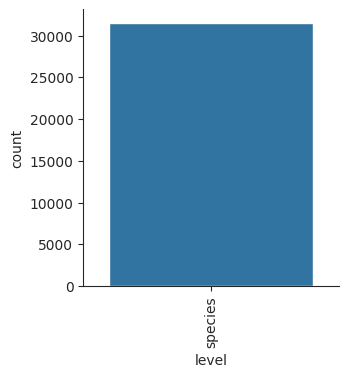

In [25]:
g = sns.catplot(
    data=taxonomy_output_counts.value_counts(subset=['level']).reset_index(),
    x='level', y='count', kind='bar', height=3.5
)
g.set_xticklabels(rotation=90)

## Saving

In [26]:
taxonomy_output_counts.to_json(product['count'], orient='records')